[*********************100%***********************]  1 of 1 completed


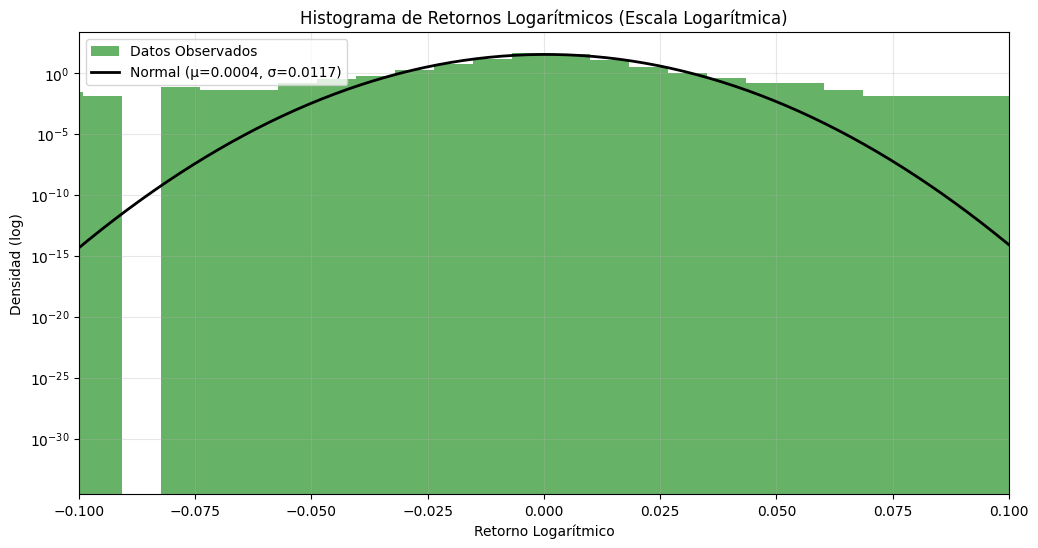

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
from scipy.stats import gaussian_kde

# Download and process data
data = yf.download('SPY', start='1980-01-01', end='2026-01-01', auto_adjust=False)
log_ret = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna().values.flatten()

# Setup x-axis range for plotting
x = np.linspace(-0.1, 0.1, 500)

# Empirical density estimation using KDE
kde = gaussian_kde(log_ret, bw_method='scott')
empirical_density = kde(x)

# Fit distributions
mu, std = stats.norm.fit(log_ret)
print(f"Ajustando Lévy estable...")
params_levy = stats.levy_stable.fit(log_ret)
alpha, beta, loc, scale = params_levy
print(f"Lévy: α={alpha:.3f}, β={beta:.3f}, loc={loc:.5f}, scale={scale:.5f}")

# Calculate theoretical densities
normal_density = stats.norm.pdf(x, mu, std)
levy_density = stats.levy_stable.pdf(x, *params_levy)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(x, empirical_density, s=10, alpha=0.7, color='green', 
           label='Densidad Empírica (KDE)', zorder=3)
ax.plot(x, normal_density, 'k-', linewidth=2, 
        label=f'Normal (μ={mu:.4f}, σ={std:.4f})', zorder=2)
ax.plot(x, levy_density, 'r-', linewidth=2, 
        label=f'Lévy Estable (α={alpha:.3f}, β={beta:.3f})', zorder=1)

ax.set_yscale('log')
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(bottom=1e-2)
ax.set_xlabel('Retorno Logarítmico')
ax.set_ylabel('Densidad (log)')
ax.set_title('Distribución de Retornos Logarítmicos: Empírica vs Teórica')
ax.legend(loc='best')
ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\m'
C:\Users\migue\AppData\Local\Temp\ipykernel_15080\983032218.py:34: SyntaxWarning: invalid escape sequence '\s'
  ax[0].set_ylabel(f'Volatilidad Anualizada $(\sigma)$')
C:\Users\migue\AppData\Local\Temp\ipykernel_15080\983032218.py:43: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel(f'Drift Anualizado $(\mu)$')
C:\Users\migue\AppData\Local\Temp\ipykernel_15080\983032218.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  static_sigma = float(log_returns.std() * np.sqrt(252))
C:\Users\migue\AppData\Local\Temp\ipykernel_15080\983032218.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) 

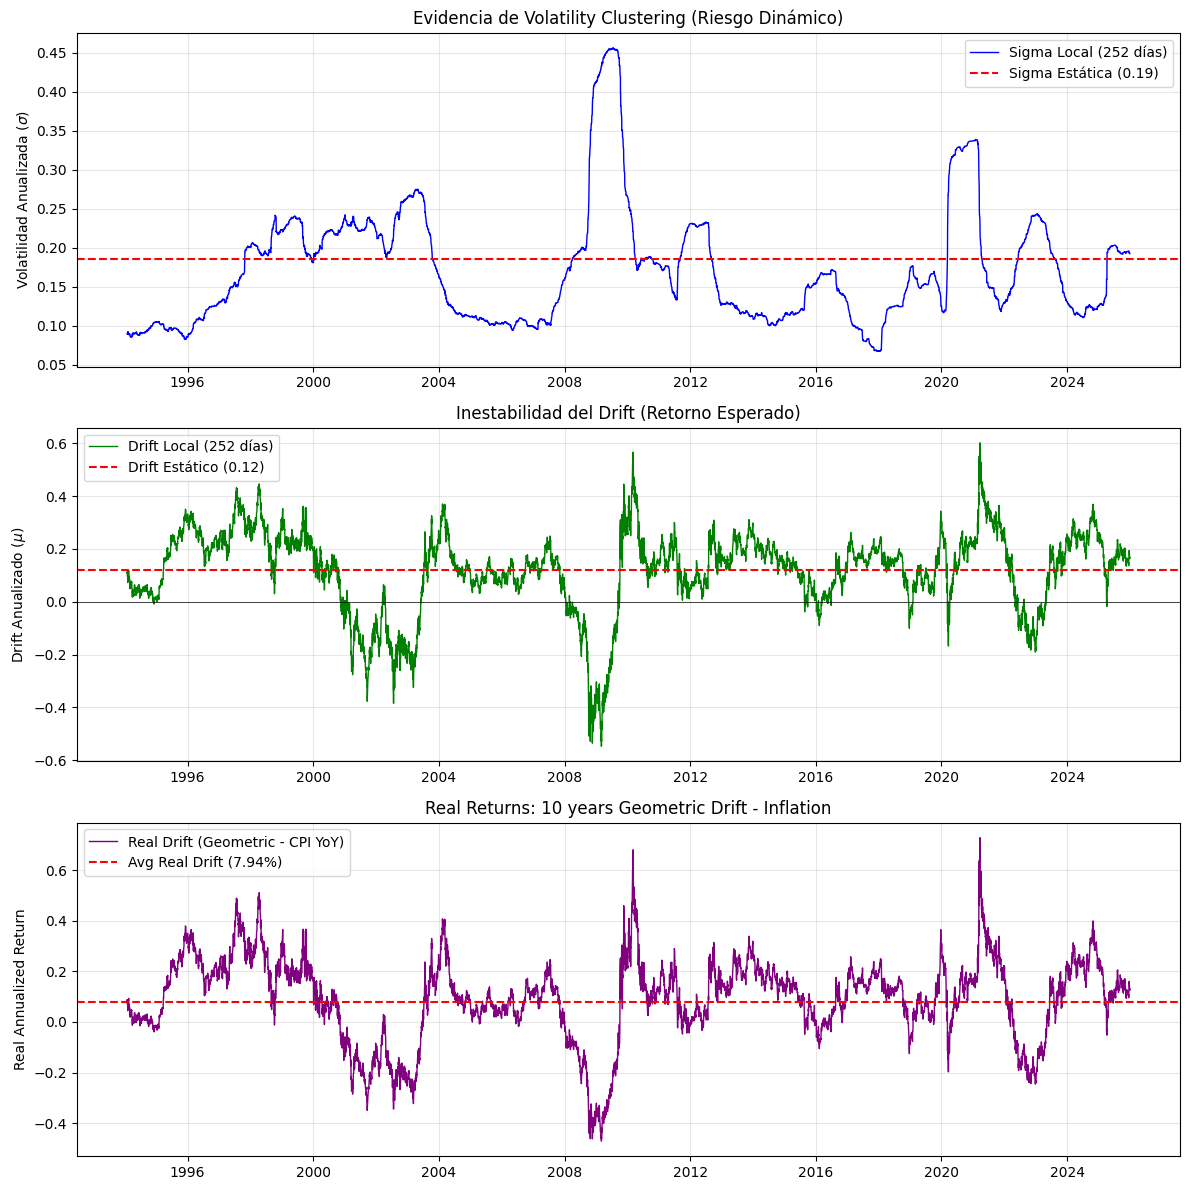

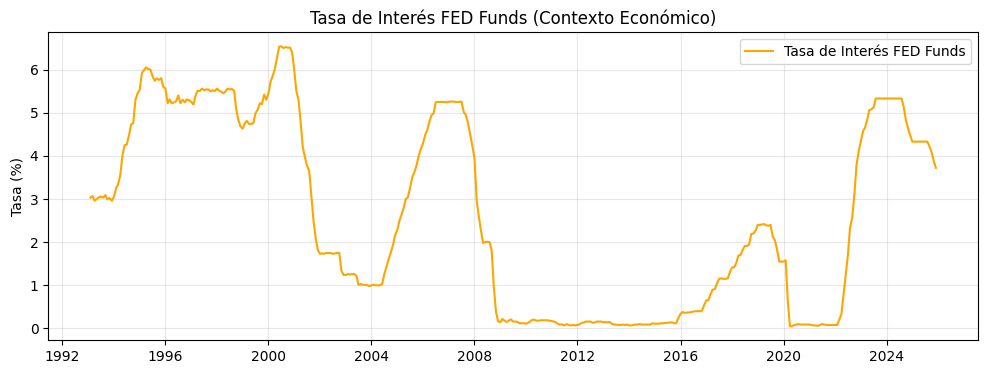

--- Diagnóstico del Paciente (SPY) ---
Curtosis (Exceso): 11.40 (Normal = 0.0)
Sesgo (Skewness):  -0.25 (Normal = 0.0)
VEREDICTO: Distribución Leptocúrtica. El modelo Gaussiano subestima el riesgo extremo.


In [8]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# --- 1. Obtención de Datos ---
ticker = 'SPY'
data = yf.download(ticker, start='1970-01-01', end='2026-01-01', progress=False, auto_adjust=False)
log_returns = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

# --- 2. Análisis de Ventana Móvil (Rolling Analysis) ---
window = 252 # Ventana de 10 años (aprox)

# Calculamos mu y sigma locales (anualizados)
rolling_geo_drift = log_returns.rolling(window).mean() * 252
rolling_sigma = log_returns.rolling(window).std() * np.sqrt(252)
# Corrección de Itô para el Drift geométrico local
rolling_drift = rolling_geo_drift + 0.5 * rolling_sigma**2

# Parámetros Estáticos (Benchmark) para todo el periodo
static_sigma = float(log_returns.std() * np.sqrt(252))
static_drift = float(log_returns.mean() * 252 + 0.5 * static_sigma**2)


# --- 3. Visualización de la No-Estacionariedad ---
fig, ax = plt.subplots(3, 1, figsize=(12, 12))

# Panel 1: El mito de la Sigma constante
ax[0].plot(rolling_sigma.index, rolling_sigma, label=f'Sigma Local ({window} días)', color='blue', linewidth=1)
ax[0].axhline(static_sigma, color='red', linestyle='--', label=f'Sigma Estática ({static_sigma:.2f})')
ax[0].set_title('Evidencia de Volatility Clustering (Riesgo Dinámico)')
ax[0].set_ylabel(f'Volatilidad Anualizada $(\sigma)$')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Panel 2: El mito del Drift constante
ax[1].plot(rolling_drift.index, rolling_drift, label=f'Drift Local ({window} días)', color='green', linewidth=1)
ax[1].axhline(static_drift, color='red', linestyle='--', label=f'Drift Estático ({static_drift:.2f})')
ax[1].axhline(0, color='black', linewidth=0.5)
ax[1].set_title('Inestabilidad del Drift (Retorno Esperado)')
ax[1].set_ylabel(f'Drift Anualizado $(\mu)$')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

import pandas as pd
import pandas_datareader.data as web

# 1. Get dates from your existing data to minimize download size
start_date = rolling_geo_drift.index[0]
end_date = rolling_geo_drift.index[-1]

# 2. Download CPI (Consumer Price Index) from FRED
# 'CPIAUCSL': All Urban Consumers, Seasonally Adjusted
try:
    cpi = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)
except Exception as e:
    print(f"Error downloading FRED data: {e}")
    # Fallback to a flat rate if download fails (optional safety net)
    cpi = pd.DataFrame({'CPIAUCSL': [100]}, index=[start_date]) 

# 3. Calculate Annual Inflation Rate (YoY % Change)
# We use pct_change(12) assuming monthly data to get the annual rate
inflation_monthly = cpi.pct_change(12)

# 4. Align Inflation to Daily Stock Data
# Reindex the monthly inflation to match your daily stock portfolio index.
# method='ffill' propagates the last known monthly rate to every day of that month.
inflation_daily = inflation_monthly.reindex(rolling_geo_drift.index, method='ffill')

# Fill NaN at the start (first 12 months won't have YoY data) with 0 or the first valid value
inflation_daily = inflation_daily.fillna(method='bfill').fillna(0)

# Ensure it's a Series, not a DataFrame column, for subtraction
inflation_series = inflation_daily['CPIAUCSL']

# --- PLOTTING ---

# Panel 3: Real Returns (Drift - Inflation)
# Note: rolling_geo_drift is (μ - σ²/2). We subtract π (inflation_series).
total_return = np.exp(rolling_geo_drift.values.flatten() - np.log(1+inflation_series.values))-1

ax[2].plot(rolling_geo_drift.index, total_return, label=f'Real Drift (Geometric - CPI YoY)', color='purple', linewidth=1)

# For the static line, we generally subtract the *average* inflation over the period
avg_inflation = inflation_series.mean()
real_return = float(log_returns.mean() * 252 - avg_inflation)
real_return = float(np.exp(log_returns.mean() * 252 - np.log(1+inflation_series.values).mean()) - 1)

ax[2].axhline(real_return, color='red', linestyle='--', label=f'Avg Real Drift ({real_return:.2%})')

ax[2].set_title('Real Returns: 10 years Geometric Drift - Inflation')
ax[2].set_ylabel('Real Annualized Return')
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Plot the FED Funds Rate for context
fed_funds = web.DataReader('FEDFUNDS', 'fred', start_date, end_date)
plt.figure(figsize=(12, 4))
plt.plot(fed_funds.index, fed_funds['FEDFUNDS'], label='Tasa de Interés FED Funds', color='orange')
plt.title('Tasa de Interés FED Funds (Contexto Económico)')
plt.ylabel('Tasa (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
    
# --- 4. Métricas de "Falsabilidad" ---
kurtosis = stats.kurtosis(log_returns).item()
skewness = stats.skew(log_returns).item()

print(f"--- Diagnóstico del Paciente ({ticker}) ---")
print(f"Curtosis (Exceso): {kurtosis:.2f} (Normal = 0.0)")
print(f"Sesgo (Skewness):  {skewness:.2f} (Normal = 0.0)")
if kurtosis > 1.0:
    print("VEREDICTO: Distribución Leptocúrtica. El modelo Gaussiano subestima el riesgo extremo.")
else:
    print("VEREDICTO: Distribución cercana a la Normal.")



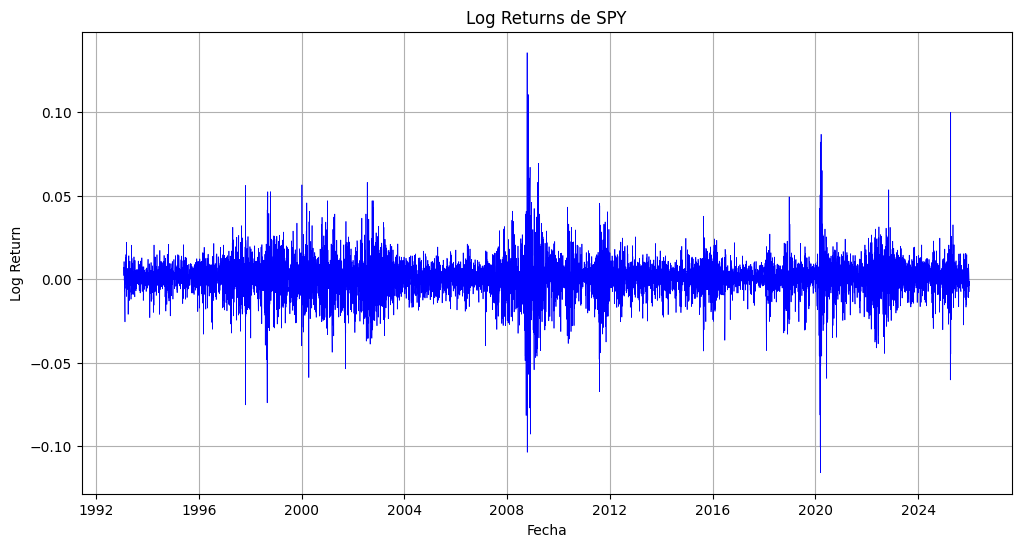

In [10]:
#Plot de los log returns para visualizar su distribución

plt.figure(figsize=(12, 6))
plt.plot(log_returns.index, log_returns, label='Log Returns', color='blue', linewidth=0.5)
plt.title('Log Returns de SPY')
plt.xlabel('Fecha')
plt.ylabel('Log Return')
plt.grid()
plt.show()
